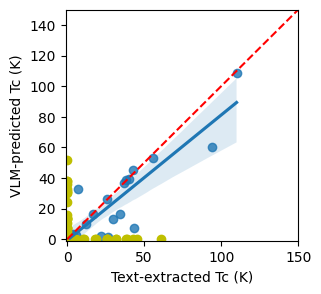

Pearson R^2: 0.779
Mean Absolute Error: 8.34 K
Matched points: 23/121 (19.0%)
Only Tc text points: 20/121 (16.5%)
Only Tc VLM points: 37/121 (30.6%)
Both Tc text and VLM null points: 41/121 (33.9%)
Mean Absolute Error: 42.68%


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
# from llm_synthesis.utils.style_utils import get_cmap, get_palette, set_style

# set_style()

df = pd.read_csv('/home/magled/lematerial-llm-synthesis/results/selected_papers/results/tc_master.csv')

# paper_id,year,material,material_normalized,is_superconductor,tc_text,tc_text_onset,tc_text_zero,tc_text_source,tc_vlm,tc_vlm_onset,tc_vlm_zero,tc_vlm_source,tc_vlm_source_plot,tc_best,tc_best_source,has_text_tc,has_vlm_tc,synthesis_method,synthesis_score

import seaborn as sns

plt.figure(figsize=(3,3))
sns.regplot(x='tc_text', y='tc_vlm', data=df.dropna(subset=['tc_text', 'tc_vlm']), ci=95)
plt.xlabel('Text-extracted Tc (K)')
plt.ylabel('VLM-predicted Tc (K)')
plt.plot([0, 150], [0, 150], 'r--')

# add unmatched points as red dots
plt.scatter(df[df['tc_vlm'].isnull()]['tc_text'], [0] * df[df['tc_vlm'].isnull()].shape[0], c='y', marker='o')
plt.scatter([0] * df[df['tc_text'].isnull()].shape[0], df[df['tc_text'].isnull()]['tc_vlm'], c='y', marker='o')

plt.xlim(-1, 150)
plt.ylim(-1, 150)

plt.show()

pearson_r2 = df.dropna(subset=['tc_text', 'tc_vlm'])[['tc_text', 'tc_vlm']].corr().iloc[0, 1] ** 2
print(f'Pearson R^2: {pearson_r2:.3f}')
mae = (df.dropna(subset=['tc_text', 'tc_vlm']).assign(abs_error=lambda x: (x['tc_text'] - x['tc_vlm']).abs()))['abs_error'].mean()
print(f'Mean Absolute Error: {mae:.2f} K')

# % of matched points (matrix of tc text and tc_vlm)
matched_points = df.dropna(subset=['tc_text', 'tc_vlm']).shape[0]
total_points = df.shape[0]
matched_percentage = matched_points / total_points * 100

print(f'Matched points: {matched_points}/{total_points} ({matched_percentage:.1f}%)')

# % only tc text points
only_tc_text_points = df[df['tc_vlm'].isnull() & df['tc_text'].notnull()].shape[0]
only_tc_text_percentage = only_tc_text_points / total_points * 100
print(f'Only Tc text points: {only_tc_text_points}/{total_points} ({only_tc_text_percentage:.1f}%)')

# % only tc vlm points
only_tc_vlm_points = df[df['tc_text'].isnull() & df['tc_vlm'].notnull()].shape[0]
only_tc_vlm_percentage = only_tc_vlm_points / total_points * 100
print(f'Only Tc VLM points: {only_tc_vlm_points}/{total_points} ({only_tc_vlm_percentage:.1f}%)')

# the rest are points where both tc text and tc vlm are null
both_null_points = df[df['tc_text'].isnull() & df['tc_vlm'].isnull()].shape[0]
both_null_percentage = both_null_points / total_points * 100
print(f'Both Tc text and VLM null points: {both_null_points}/{total_points} ({both_null_percentage:.1f}%)')

# mae in percent
mae_percent = (df.dropna(subset=['tc_text', 'tc_vlm']).assign(abs_error=lambda x: (x['tc_text'] - x['tc_vlm']).abs() / x['tc_text'] * 100))['abs_error'].mean()
print(f'Mean Absolute Error: {mae_percent:.2f}%')